In [1]:
# %% [markdown]
# # Waste Classification using ResNet50
# This notebook builds a multi-class image classifier for 10 types of waste using a pre-trained ResNet50 model.

# %%
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create directory to save plots
os.makedirs('plots', exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# %% [markdown]
# ## 1. Dataset Loading and Exploration
# We'll load the dataset paths and count images per class to verify structure.

# %%
dataset_path = 'Dataset'  # Change if your folder is elsewhere
classes = os.listdir(dataset_path)
classes.sort()
print(f"Found {len(classes)} classes: {classes}")

# Count images per class
image_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        image_counts[cls] = len(images)
        print(f"{cls}: {len(images)} images")

# Total images
total_images = sum(image_counts.values())
print(f"\nTotal images: {total_images}")

Found 10 classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
battery: 756 images
biological: 699 images
cardboard: 1411 images
clothes: 1892 images
glass: 1736 images
metal: 930 images
paper: 1336 images
plastic: 1597 images
shoes: 1449 images
trash: 453 images

Total images: 12259


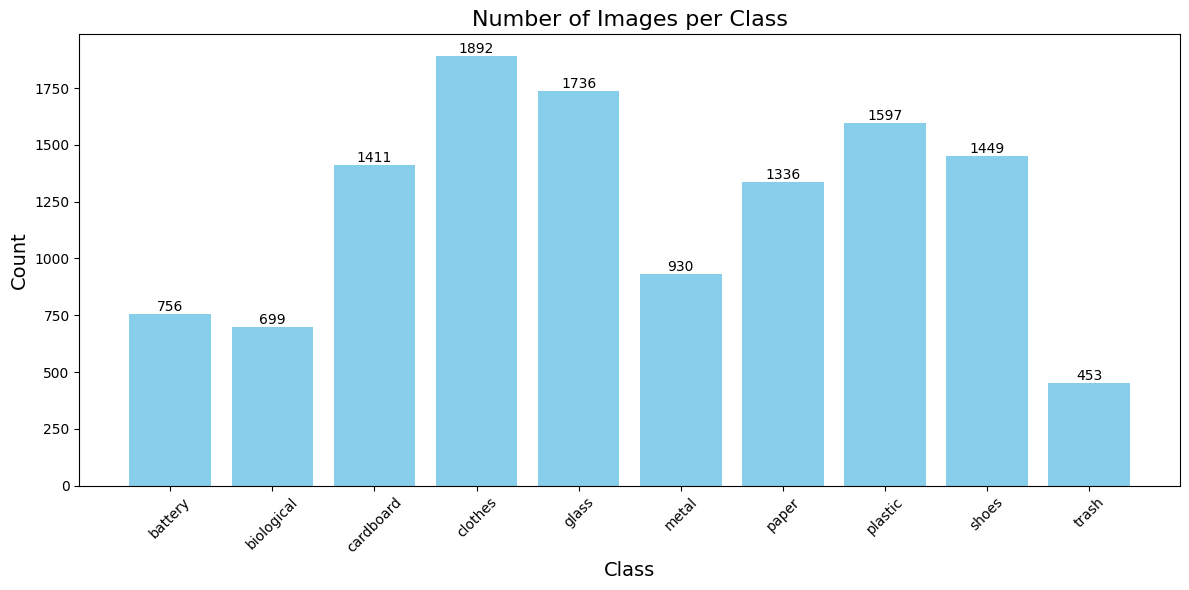

In [3]:
# %% [markdown]
# ## 2. Data Visualization – Class Distribution
# Plot a bar chart showing the number of images per class.

# %%
plt.figure(figsize=(12,6))
bars = plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.title('Number of Images per Class', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=150)
plt.show()

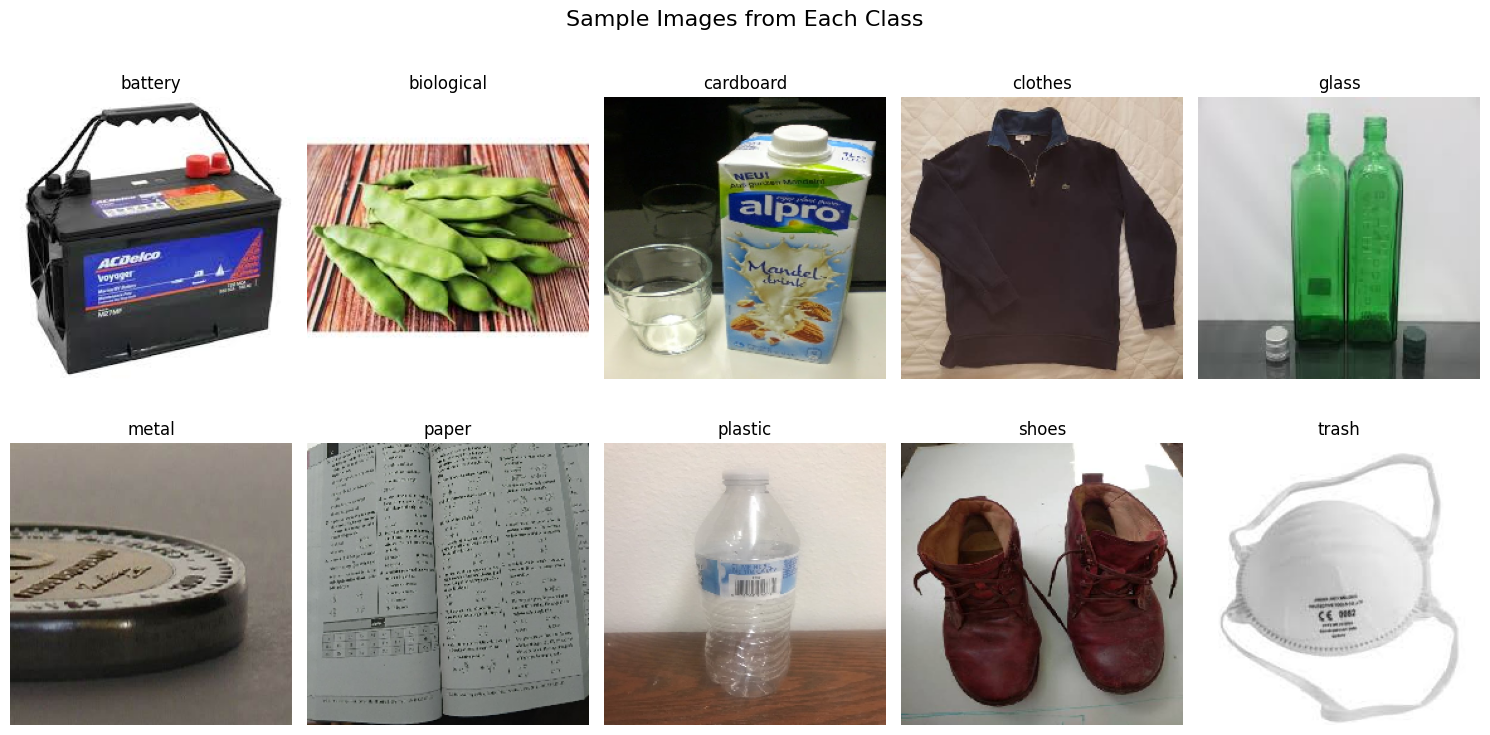

In [4]:
# %% [markdown]
# ## 3. Visualize Sample Images from Each Class
# Display one random image per class.

# %%
plt.figure(figsize=(15, 8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if img_files:
        img_path = os.path.join(cls_path, np.random.choice(img_files))
        img = load_img(img_path, target_size=(224,224))  # ResNet50 default size
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout()
plt.savefig('plots/sample_images.png', dpi=150)
plt.show()

In [5]:
# %% [markdown]
# ## 4. Data Preprocessing and Augmentation
# We'll use `ImageDataGenerator` for:
# - Rescaling pixel values to [0,1]
# - Data augmentation (rotation, zoom, flip, etc.) on training set only.
# - Splitting into training and validation (80/20) using `validation_split`.

# %%
# Image dimensions expected by ResNet50
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2          # if you want to split automatically
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Save class indices for later use
class_indices = train_generator.class_indices
print("\nClass indices:", class_indices)

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.

Class indices: {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


In [6]:
# %% [markdown]
# ## 5. Feature Engineering
# The augmentation steps above (rotation, zoom, etc.) artificially expand the training dataset and help the model generalize better. No manual feature extraction is needed for CNNs.

In [7]:
# %% [markdown]
# ## 6. Model Creation
# Load ResNet50 pre-trained on ImageNet, remove top layers, add custom classifier.

# ================================
# 6. Model Creation
# ================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


def create_model(learning_rate=0.001):

    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=(224,224,3))

    # Freeze base model
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model


# Create model
model, base_model = create_model()

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=25,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/25
306/306 [==============================] - ETA: 0s - loss: 2.1882 - accuracy: 0.1913

In [ ]:
# %% [markdown]
# ## 8. Fine-tuning
# Unfreeze the top layers of ResNet50 and continue training with a lower learning rate.

# %%
# Unfreeze the base model
# Unfreeze base model
for layer in base_model.layers:
    layer.trainable = True

# Recompile with lower LR
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

# Combine histories
history['loss'].extend(history_phase2.history['loss'])
history['accuracy'].extend(history_phase2.history['accuracy'])
history['val_loss'].extend(history_phase2.history['val_loss'])
history['val_accuracy'].extend(history_phase2.history['val_accuracy'])


history=history_phase2

In [ ]:
# %% [markdown]
# ## 9. Plot Training and Validation Curves

# %%
epochs_range = range(1, len(history['loss'])+1)

plt.figure(figsize=(14,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs_range, history['loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('plots/training_history.png', dpi=150)
plt.show()

In [ ]:
# %% [markdown]
# ## 10. Performance Evaluation
# Compute precision, recall, f1-score, confusion matrix, and ROC curves.

# %%
# Get predictions for validation set
validation_generator.reset()
y_pred_prob = model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = validation_generator.classes[:len(y_pred)]  # align lengths

# Class names
class_names = list(class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150)
plt.show()

# ROC Curves (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', len(class_names))
for i, color in zip(range(len(class_names)), colors.colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('plots/roc_curves.png', dpi=150)
plt.show()

In [ ]:
# %% [markdown]
# ## 11. Hyperparameter Tuning
# We'll try different learning rates and batch sizes for a few epochs to find a good combination, then retrain the best model fully.

# %%
# Define candidate hyperparameters
learning_rates = [0.0001, 0.001]
batch_sizes = [32, 64]
epochs_tune = 5  # quick run

best_val_acc = 0
best_params = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n--- Testing LR={lr}, Batch Size={bs} ---")
        
        # Create new generators with current batch size
        train_gen_tune = train_datagen.flow_from_directory(
            dataset_path,
            target_size=IMG_SIZE,
            batch_size=bs,
            class_mode='categorical',
            subset='training',
            seed=42
        )
        val_gen_tune = val_datagen.flow_from_directory(
            dataset_path,
            target_size=IMG_SIZE,
            batch_size=bs,
            class_mode='categorical',
            subset='validation',
            shuffle=False,
            seed=42
        )
        
        # Build model
        model_tune = create_model(learning_rate=lr)
        
        # Train for few epochs
        h = model_tune.fit(
            train_gen_tune,
            steps_per_epoch=train_gen_tune.samples // bs,
            validation_data=val_gen_tune,
            validation_steps=val_gen_tune.samples // bs,
            epochs=epochs_tune,
            verbose=0
        )
        
        val_acc = h.history['val_accuracy'][-1]
        print(f"Validation accuracy after {epochs_tune} epochs: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = {'lr': lr, 'batch_size': bs}

print(f"\nBest hyperparameters: {best_params} with validation accuracy {best_val_acc:.4f}")

In [ ]:
# %% [markdown]
# ## 12. Cross-Validation (Stratified K-Fold)
# Perform 3-fold cross-validation to assess model stability. Since the dataset is moderate, we'll use a subset of data for speed.

# %%
# Load all file paths and labels for k-fold
file_paths = []
labels = []
for cls in class_names:
    cls_path = os.path.join(dataset_path, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_paths.append(os.path.join(cls_path, fname))
            labels.append(class_indices[cls])

file_paths = np.array(file_paths)
labels = np.array(labels)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
    print(f"\n--- Fold {fold+1} ---")
    
    # Create data generators for this fold
    train_files_fold = file_paths[train_idx]
    val_files_fold = file_paths[val_idx]
    train_labels_fold = labels[train_idx]
    val_labels_fold = labels[val_idx]
    
    # Use ImageDataGenerator with flow_from_dataframe (simpler for custom splits)
    train_df = pd.DataFrame({'filename': train_files_fold, 'class': train_labels_fold})
    val_df = pd.DataFrame({'filename': val_files_fold, 'class': val_labels_fold})
    
    train_datagen_fold = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
    val_datagen_fold = ImageDataGenerator(rescale=1./255)
    
    train_gen_fold = train_datagen_fold.flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )
    val_gen_fold = val_datagen_fold.flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    
    # Build model
    model_fold = create_model(learning_rate=0.001)
    
    # Train for a few epochs (e.g., 5)
    h_fold = model_fold.fit(
        train_gen_fold,
        steps_per_epoch=len(train_gen_fold),
        validation_data=val_gen_fold,
        validation_steps=len(val_gen_fold),
        epochs=5,
        verbose=0
    )
    
    val_acc_fold = h_fold.history['val_accuracy'][-1]
    fold_accuracies.append(val_acc_fold)
    print(f"Fold validation accuracy: {val_acc_fold:.4f}")

print(f"\nCross-validation accuracies: {fold_accuracies}")
print(f"Mean CV accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")

In [ ]:
# %% [markdown]
# ## 13. Train Final Model with Best Parameters
# Using the best hyperparameters from tuning, we train the final model fully (including fine-tuning).

# %%
best_lr = best_params.get('lr', 0.001)
best_bs = best_params.get('batch_size', 32)

print(f"Training final model with LR={best_lr}, Batch Size={best_bs}")

# Create generators with best batch size
train_gen_final = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=best_bs,
    class_mode='categorical',
    subset='training',
    seed=42
)
val_gen_final = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=best_bs,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Build model
final_model = create_model(learning_rate=best_lr)

# Phase 1 training (frozen base)
history_final_phase1 = final_model.fit(
    train_gen_final,
    steps_per_epoch=train_gen_final.samples // best_bs,
    validation_data=val_gen_final,
    validation_steps=val_gen_final.samples // best_bs,
    epochs=10,
    verbose=1
)

# Fine-tuning
final_model.trainable = True
for layer in final_model.layers[:100]:
    layer.trainable = False
final_model.compile(optimizer=Adam(learning_rate=best_lr/10), loss='categorical_crossentropy', metrics=['accuracy'])

history_final_phase2 = final_model.fit(
    train_gen_final,
    steps_per_epoch=train_gen_final.samples // best_bs,
    validation_data=val_gen_final,
    validation_steps=val_gen_final.samples // best_bs,
    epochs=15,
    verbose=1
)

# Combine histories for final model
final_history = {}
final_history['loss'] = history_final_phase1.history['loss'] + history_final_phase2.history['loss']
final_history['accuracy'] = history_final_phase1.history['accuracy'] + history_final_phase2.history['accuracy']
final_history['val_loss'] = history_final_phase1.history['val_loss'] + history_final_phase2.history['val_loss']
final_history['val_accuracy'] = history_final_phase1.history['val_accuracy'] + history_final_phase2.history['val_accuracy']

In [ ]:
# %% [markdown]
# ## 14. Final Model Evaluation
# Re-run evaluation on validation set using final model.

# %%
val_gen_final.reset()
y_pred_prob_final = final_model.predict(val_gen_final, steps=val_gen_final.samples // best_bs + 1)
y_pred_final = np.argmax(y_pred_prob_final, axis=1)
y_true_final = val_gen_final.classes[:len(y_pred_final)]

print("Final Model Classification Report:")
print(classification_report(y_true_final, y_pred_final, target_names=class_names))

# Confusion Matrix
cm_final = confusion_matrix(y_true_final, y_pred_final)
plt.figure(figsize=(10,8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Model Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/final_confusion_matrix.png', dpi=150)
plt.show()

# Plot final training curves
epochs_range_final = range(1, len(final_history['loss'])+1)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs_range_final, final_history['loss'], label='Training Loss')
plt.plot(epochs_range_final, final_history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Final Model Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range_final, final_history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range_final, final_history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Final Model Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/final_training_history.png', dpi=150)
plt.show()

In [ ]:
# %% [markdown]
# ## 15. Save Model
# Save the final model in `.h5` format for easy loading later.

# %%
final_model.save('waste_classification_resnet50.h5')
print("Model saved as waste_classification_resnet50.h5")

In [ ]:
# %% [markdown]
# ## 16. Load Saved Model and Predict on a Test Image
# Demonstrate loading the model and making a prediction on a single image.

# %%
from tensorflow.keras.preprocessing import image

def load_and_preprocess_image(img_path, target_size=(224,224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Rescale
    return img_array

# Load the saved model
loaded_model = load_model('waste_classification_resnet50.h5')

# Choose a test image (replace with your own)
test_img_path = 'Dataset/Plastic/plastic1.jpg'  # example, change accordingly
if os.path.exists(test_img_path):
    img_array = load_and_preprocess_image(test_img_path)
    
    # Predict
    preds = loaded_model.predict(img_array)
    predicted_class_idx = np.argmax(preds[0])
    predicted_class = class_names[predicted_class_idx]
    confidence = np.max(preds[0])
    
    # Display image with prediction
    img_display = image.load_img(test_img_path)
    plt.imshow(img_display)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis('off')
    plt.show()
else:
    print("Test image not found. Please provide a valid path.")

In [ ]:
# %% [markdown]
# ## 17. Conclusion
# This notebook demonstrated a complete deep learning pipeline for waste classification using ResNet50. Key steps included:
# - Data exploration and visualization
# - Data augmentation and preprocessing
# - Transfer learning with fine-tuning
# - Hyperparameter tuning and cross-validation
# - Comprehensive evaluation with metrics and plots
# - Model saving and loading for inference
# 
# The final model is saved as `waste_classification_resnet50.h5` and can be deployed in applications for automated waste sorting.